# Predicting a segment's share next month (Task A)

**The question:** for a segment (a specialty × age band × gender), can a model estimate Zilretta's share *next month* better than the simple guesses, and can it tell which segments will sit above or below the market?

**The answer, in one line:** modestly, yes. A simple model that blends a segment's last three months with its longer history estimates next month's share better than "same as last month", consistently, mostly for small segments. The gain for large segments is negligible, and the estimates run about 7% high in the declining period we tested on.

This notebook shows the evidence step by step: the label audit that changed the plan, the baselines, three models, and the judging (calibration, wins by month, where the gain comes from, what the model uses, how stable the verdict is). Decisions: DL-48 to DL-51. Everything in the protocol was fixed in `docs/phase4_modeling_plan.md` before the runs.

> The live runs take about 10 minutes. The three exclusion re-runs (without PEDIATRICS, the COVID months, and the 2024 dip) take about 20 more, so they are shown as a recorded table with a switch to re-run them.

In [1]:
import sys
import time
import warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

from oa_market_intelligence.features.segment import load_segment_gold
from oa_market_intelligence.features.segment_task import TASK_A_FEATURES, audit_labels, build_task_a_rows
from oa_market_intelligence.modeling.segment_eval import (
    improvement_summary, log_loss_per_visit, mae_per_share, month_bootstrap)
from oa_market_intelligence.modeling.segment_judge import (
    a2_extras, bucket_improvement, calibration_slope, calibration_table, exclude_and_build,
    judge_rules, monthly_wins, permutation_importance, rank_agreement, serve_with_tie_break)
from oa_market_intelligence.modeling.segment_models import fitter_for
from oa_market_intelligence.modeling.segment_task_run import a2_frame, run_a1, run_a2

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 160)

engine = create_engine("sqlite:///../data/published/warehouse.db")
seg = load_segment_gold(engine)
print(f"{len(seg)} segment-month rows, {seg.groupby(['specialty_name','age_band','gender']).ngroups} segments, 72 months")

21636 segment-month rows, 634 segments, 72 months


## 1. What we predict, and the rule that keeps it honest

Each row is one segment in one month *t*. **Every input uses only data from month *t-1* or earlier**: the segment's share last month, its average over the last three months, its long-run share, the specialty's long-run share, last month's market-wide share, last month's visit count, age, gender and the calendar. The answer (month *t*'s share and counts) is kept in separate columns with a `y_` prefix that a model is never shown.

A prediction is made only for segments with at least 20 category visits in month *t-1* (so they have a history). That gives 8,450 prediction rows over 70 months.

**Test design (walk-forward).** To predict month *t* the model is trained on every row from months before *t* (at least 24 months), then predicts month *t*, and this repeats for 46 test months. A model never sees the month it is predicting, and the test month never influences any setting.

**Checking there is no leak.** The next cell rewrites every month from a cut month onward with random numbers and asks whether any input for the earlier months moved. If an input used future data it would.

In [2]:
rows = build_task_a_rows(seg)
two = build_task_a_rows(seg, scheme="two_label")
rng = np.random.default_rng(0)
keys = ["month_id", "specialty_name", "age_band", "gender"]
cols = [c for c in TASK_A_FEATURES if c != "specialty_grouped"]
for cut in (202006, 202212, 202406):
    mod = seg.copy()
    later = mod["month_id"] >= cut
    t = rng.integers(60, 400, later.sum())
    mod.loc[later, "total_category_visits"] = t
    mod.loc[later, "branded_injectable_visits"] = rng.binomial(t, 0.4)
    after = build_task_a_rows(mod)
    b = rows[rows["month_id"] <= cut].merge(after[after["month_id"] <= cut], on=keys, suffixes=("_a", "_b"))
    worst = max(np.nanmax(np.abs(b[f"{c}_a"].to_numpy(float) - b[f"{c}_b"].to_numpy(float))) for c in cols)
    print(f"months rewritten from {cut}: compared {len(b):5d} earlier rows; largest change in any input: {worst:.3g}")

months rewritten from 202006: compared  1072 earlier rows; largest change in any input: 0
months rewritten from 202212: compared  4784 earlier rows; largest change in any input: 0


months rewritten from 202406: compared  6967 earlier rows; largest change in any input: 0


## 2. The label audit that changed the plan

The first idea was a three-way label for each segment-month: **High** if the segment's share is clearly above the market-wide share that month (the whole 95% interval is above it), **Low** if clearly below, and **undetermined** otherwise. It was only to be used if at least 3,000 rows were scored and each class had at least 15% of them. That gate was fixed before the data was looked at.

In [3]:
def flips(d, label_col):
    pred = np.where(d["seg_high_lag1"] == 1, "High", "Low")
    return int((pred != d[label_col]).sum())

audit_rows = []
a = audit_labels(rows)
sc = rows[rows["y_label"] != "Undetermined"]
audit_rows.append({"scheme": "three labels, 95% interval (planned)", "rows scored": a["n_scored"], "share High": round(a["high_share"], 3),
                   "'same as last month' balanced accuracy": round(a["persistence_balanced_accuracy"], 3), "label changes": flips(sc, "y_label"), "passes the gate": a["passes"]})
a90 = audit_labels(build_task_a_rows(seg, z=1.645))
audit_rows.append({"scheme": "three labels, 90% interval", "rows scored": a90["n_scored"], "share High": round(a90["high_share"], 3),
                   "'same as last month' balanced accuracy": round(a90["persistence_balanced_accuracy"], 3), "label changes": None, "passes the gate": a90["passes"]})
a2 = audit_labels(two)
audit_rows.append({"scheme": "two labels, 100+ visits last month (fallback)", "rows scored": a2["n_scored"], "share High": round(a2["high_share"], 3),
                   "'same as last month' balanced accuracy": round(a2["persistence_balanced_accuracy"], 3), "label changes": flips(two, "y_label"), "passes the gate": a2["passes"]})
print(pd.DataFrame(audit_rows).to_string(index=False))

                                       scheme  rows scored  share High  'same as last month' balanced accuracy  label changes  passes the gate
         three labels, 95% interval (planned)         2355       0.616                                   0.938          164.0            False
                   three labels, 90% interval         3009       0.571                                   0.918            NaN             True
two labels, 100+ visits last month (fallback)         5436       0.469                                   0.819          979.0             True


**What this shows.**

- The planned scheme **fails the gate**: only 2,355 rows are scored (72% are undetermined, mostly small segments whose share cannot be told from the market's).
- A 90% interval would scrape through (3,009 rows), but it was **not adopted**: the gate and the fallback were fixed beforehand, and loosening them after seeing the data is exactly the tuning the plan forbids.
- The pre-specified fallback applies: two labels (above or below the market-wide share), for segments with at least 100 visits last month. That leaves 5,436 rows.
- The important discovery: **these labels barely change.** "Same side of the market as last month" is right about 82% of the time on the fallback rows (93% on the clear rows), and only about 980 rows in 70 months change side. A model that only predicts the label has very little to learn from, and a test on the label alone has little power to show a real gain.

So the plan was changed (decision DL-49): the **primary test predicts each segment's share next month** from its visit counts (it uses all 8,450 rows and the actual counts); High or Low is derived from that prediction and reported as supporting evidence.

## 3. The baselines and the three models

**Baselines** (all use only last-month-or-earlier information): the market-wide share last month; the segment's own share last month; the segment's long-run share; the specialty's long-run share. The three history shares are smoothed with half a visit of each kind so a segment with no Zilretta visits yet is not predicted to be exactly zero.

**Models.** Logistic regression (a weighted sum of the inputs turned into a share), gradient boosting and random forest (many small decision trees). Their settings are chosen **inside each training window only**: the last 12 training months are held out, each setting is tried on the months before them, and the best is refitted on everything. A tie goes to the simpler setting.

**The yardstick: log-loss per visit.** For every visit, the model is charged for how surprised it was by what happened: a small charge if it gave the outcome a good chance, a big one if it said "very unlikely" and it happened. Lower is better. It is dominated by the randomness of the counts themselves, so even a perfect model scores well above zero, and differences between good models are small. We also report the plain error in the share (average absolute gap, in percentage points), weighted by visits and not.

**The serving rule (fixed before the run).** A model is promoted over the best baseline only if the lower end of its paired improvement is above zero, using months resampled with replacement (2,000 draws), and with a stricter 1.67th percentile (a correction for trying three models). Among promoted models the simplest serves unless a more complex one is clearly better.

In [4]:
t0 = time.time()
a1 = run_a1(rows, n_boot=2000, seed=0)
a2r = run_a2(a1, two, n_boot=2000, seed=0)
print(f"walk-forward over {a1['preds']['market']['month_id'].nunique()} test months and {len(a1['preds']['market'])} rows took {time.time()-t0:.0f}s")
scores = a1["scores"].rename(columns={"log_loss": "log-loss per visit", "mae_weighted": "share error, visit-weighted", "mae": "share error, unweighted"})
print(scores.round(5).to_string())
print("\nbest baseline:", a1["best_baseline"])

walk-forward over 46 test months and 5522 rows took 585s
                   log-loss per visit  share error, visit-weighted  share error, unweighted
market                        0.11566                      0.00997                  0.01996
last_month                    0.11317                      0.00555                  0.01497
segment_history               0.11349                      0.00704                  0.01348
specialty_history             0.11494                      0.01002                  0.01644
logistic                      0.11274                      0.00487                  0.01120
gbm                           0.11274                      0.00484                  0.01153
rf                            0.11274                      0.00478                  0.01173

best baseline: last_month


In [5]:
base = a1["best_baseline"]
rel = lambda s: s["estimate"] / a1["scores"].loc[base, "log_loss"] * 100
print("paired improvement over the best baseline, log-loss per visit (positive = model better):")
for name, s in a1["summaries"].items():
    print(f"  {name:9s} {s['estimate']:+.6f} ({rel(s):+.2f}%)   1.67th percentile {s['low']:+.6f}   share of resamples above zero {s['share_positive']:.3f}")
tie = serve_with_tie_break(a1["decision"]["promoted"], a1["stats"], a1["draws"])
print("\npromoted:", a1["decision"]["promoted"])
print("serving after the tie-break:", tie["serving"], "-", tie["reason"])
serving = tie["serving"]
pairs = month_bootstrap({n: a1["stats"][n] for n in ("logistic", "gbm", "rf")}, "log_loss", n_boot=2000, seed=0)
print("\nare the three models different from each other? (log-loss per visit, positive = first better)")
for x, y in (("gbm", "logistic"), ("rf", "logistic"), ("rf", "gbm")):
    s = improvement_summary(a1["stats"][y], a1["stats"][x], pairs[y], pairs[x], "log_loss")
    print(f"  {x} over {y}: {s['estimate']:+.7f}   interval [{s['low']:+.7f}, {s['high']:+.7f}]")

paired improvement over the best baseline, log-loss per visit (positive = model better):
  logistic  +0.000436 (+0.39%)   1.67th percentile +0.000373   share of resamples above zero 1.000
  gbm       +0.000437 (+0.39%)   1.67th percentile +0.000366   share of resamples above zero 1.000
  rf        +0.000432 (+0.38%)   1.67th percentile +0.000373   share of resamples above zero 1.000

promoted: ['logistic', 'gbm', 'rf']
serving after the tie-break: logistic - gbm is not clearly better than the simpler logistic

are the three models different from each other? (log-loss per visit, positive = first better)
  gbm over logistic: +0.0000010   interval [-0.0000359, +0.0000349]
  rf over logistic: -0.0000036   interval [-0.0000435, +0.0000364]
  rf over gbm: -0.0000046   interval [-0.0000375, +0.0000297]


**What this shows.**

- All three trained models beat "same as last month" by about 0.0004 per visit (+0.39%), and the lower end of the improvement is above zero, so all three are promoted.
- The three models are **statistically indistinguishable** from each other (differences in the sixth decimal, intervals straddling zero), so the tie-break serves the simplest, **logistic regression**. "Gradient boosting has the lowest score" would be an arbitrary pick.
- In share-error terms the gain is larger: about 12 to 14% lower visit-weighted error and 22 to 25% lower unweighted error than last month's share.

## 4. Is the gain real in most months? And where does it come from?

logistic  beats the best baseline in 44/46 months on log-loss, 39/46 on weighted share error, 46/46 on unweighted share error
gbm       beats the best baseline in 45/46 months on log-loss, 36/46 on weighted share error, 46/46 on unweighted share error
rf        beats the best baseline in 45/46 months on log-loss, 41/46 on weighted share error, 45/46 on unweighted share error

by the segment's visits last month:
 bucket    n  log-loss gain  share error: last month  share error: model
    <50  921        0.00767                   0.0292              0.0188
 50-100 1063        0.00470                   0.0207              0.0147
100-300 1614        0.00191                   0.0137              0.0113
   >300 1924        0.00013                   0.0061              0.0055


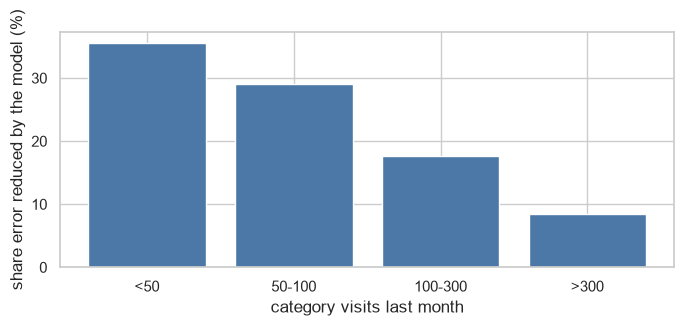

In [6]:
for name in ("logistic", "gbm", "rf"):
    w, n = monthly_wins(a1["stats"][base], a1["stats"][name], "log_loss")
    wm, _ = monthly_wins(a1["stats"][base], a1["stats"][name], "mae_weighted")
    wu, _ = monthly_wins(a1["stats"][base], a1["stats"][name], "mae")
    print(f"{name:9s} beats the best baseline in {w}/{n} months on log-loss, {wm}/{n} on weighted share error, {wu}/{n} on unweighted share error")
bi = bucket_improvement(a1["preds"][base], a1["preds"][serving])
bi["share error: last month"] = bi["mae_baseline"].round(4); bi["share error: model"] = bi["mae_model"].round(4)
bi["log-loss gain"] = bi["improvement"].round(5)
print("\nby the segment's visits last month:")
print(bi[["bucket", "n", "log-loss gain", "share error: last month", "share error: model"]].to_string(index=False))
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar(bi["bucket"], (1 - bi["mae_model"] / bi["mae_baseline"]) * 100, color="#4c78a8")
ax.set_ylabel("share error reduced by the model (%)"); ax.set_xlabel("category visits last month")
plt.tight_layout(); plt.show()

**What this shows.** The model beats last month's share in nearly every month, and almost all the gain is on small segments: for segments with fewer than 50 visits last month the share error is about 36% lower, while for segments with more than 300 visits it is only about 9% lower and the log-loss gain is close to zero. That is what you would expect: one month of data for a small segment is mostly noise, and a model that blends several months and the specialty's level cuts through it. For big segments "same as last month" is already very good.

## 5. Does it look calibrated?

Calibration asks: when the model says 3%, is the real share about 3%? The visits are sorted by the model's prediction and split into ten equal-sized groups.

   predicted share (%)  observed share (%)
0                 0.85                0.73
1                 1.46                1.29
2                 1.76                1.50
3                 2.05                1.79
4                 2.40                2.19
5                 2.67                2.50
6                 2.94                2.81
7                 3.29                3.12
8                 3.75                3.60
9                 5.31                5.23

calibration slope 1.11 (1.0 is ideal; the pre-set rule allows 0.8 to 1.2), intercept 0.30
average predicted share 2.65% against observed 2.48%


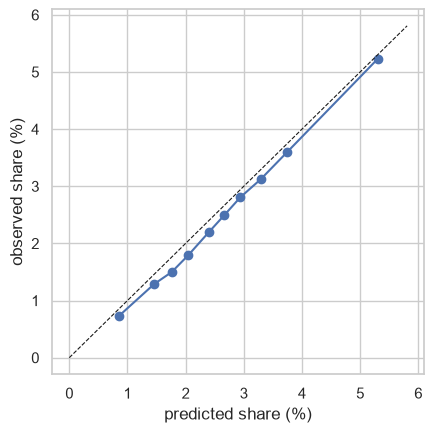

In [7]:
ct = calibration_table(a1["preds"][serving])
slope = calibration_slope(a1["preds"][serving])
print((ct[["pred", "obs"]] * 100).round(2).rename(columns={"pred": "predicted share (%)", "obs": "observed share (%)"}).to_string())
print(f"\ncalibration slope {slope['slope']:.2f} (1.0 is ideal; the pre-set rule allows 0.8 to 1.2), intercept {slope['intercept']:.2f}")
print(f"average predicted share {np.average(ct['pred'], weights=ct['visits'])*100:.2f}% against observed {np.average(ct['obs'], weights=ct['visits'])*100:.2f}%")
fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.plot(ct["pred"] * 100, ct["obs"] * 100, "o-"); lim = [0, ct["pred"].max() * 100 + 0.5]
ax.plot(lim, lim, "k--", lw=0.8); ax.set_xlabel("predicted share (%)"); ax.set_ylabel("observed share (%)")
plt.tight_layout(); plt.show()

**What this shows, and a weakness the pre-set rules did not catch.** The slope is inside the allowed range, so the model is not over- or under-confident in how it ranks things. But **every group is predicted a little too high**: about 2.65% predicted against 2.48% observed, roughly 7% too high. The test period is the decline (Oct 2021 to Jul 2025), and a model trained on earlier, higher-share months lags it. In a rising market the bias would run the other way. By specialty, low-share specialties are over-predicted and Physical Medicine & Rehab (which rose) is under-predicted: the model pulls every segment toward the average.

## 6. What does the model use?

Permutation importance: shuffle one group of inputs across the test rows and see how much worse the prediction gets (averaged over the points where the settings were re-chosen).

                   logistic regression  gradient boosting
group                                                    
own recent share               0.00401            0.00161
own history                    0.00109            0.00067
specialty history              0.00060            0.00118
demographics                   0.00023            0.00022
last month volume              0.00003            0.00002
market                         0.00000            0.00000
calendar                       0.00000            0.00000


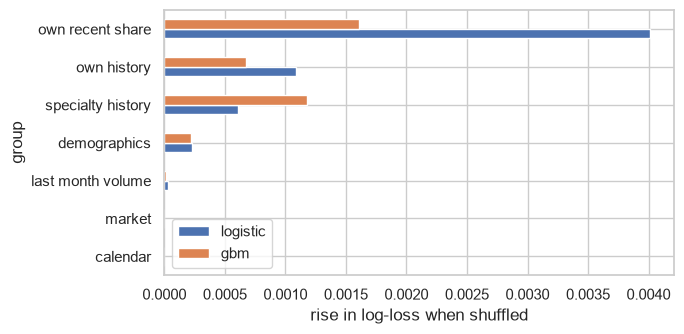

In [8]:
imp = {}
for name in ("logistic", "gbm"):
    parts = []
    for e in [e for e in a1["tuning"][name] if e["retuned"]]:
        tm = e["test_month"]
        train, test = rows[rows["month_id"] < tm], rows[rows["month_id"] == tm]
        vis = test.drop(columns=[c for c in test.columns if c.startswith("y_")])
        parts.append(permutation_importance(fitter_for(name, e["config"]), train, test, vis, n_repeats=5, seed=0)["importance"])
    imp[name] = pd.concat(parts, axis=1).mean(axis=1)
imp = pd.DataFrame(imp).sort_values("logistic", ascending=False)
print(imp.round(5).rename(columns={"logistic": "logistic regression", "gbm": "gradient boosting"}).to_string())
imp.sort_values("logistic").plot.barh(figsize=(7, 3.5)); plt.xlabel("rise in log-loss when shuffled"); plt.tight_layout(); plt.show()

**What this shows.** The model relies almost entirely on **the segment's own recent share**, then its longer history and the specialty's history. The market-wide share, the calendar and last month's volume add essentially nothing. In the logistic model the single largest numeric weight is the **three-month average share**, ahead of the segment's long-run share: averaging three months beats one month.

**Does it agree with the inference in notebook 07?** The model's predicted share by specialty can be ranked and compared with the adjusted shares from the specialty model, which was built a different way.

In [9]:
from oa_market_intelligence.analysis.adoption import (adjusted_shares, build_design, fit_binomial, group_specialties, load_adoption_data)
adopt = group_specialties(load_adoption_data(engine))
d = build_design(adopt); adj = adjusted_shares(d, adopt, fit_binomial(d, adopt))
pm = a1["preds"][serving]
by_spec = pm.groupby("specialty_name").apply(lambda g: pd.Series({"visits": g["t"].sum(), "predicted": (g["p"] * g["t"]).sum() / g["t"].sum(), "observed": g["z"].sum() / g["t"].sum()}))
print("rank agreement, model's predicted share by specialty vs the adjusted shares from notebook 07:", round(rank_agreement(by_spec["predicted"], adj), 2))
print((by_spec.sort_values("visits", ascending=False).head(11) * [1, 100, 100]).round(2).to_string())

rank agreement, model's predicted share by specialty vs the adjusted shares from notebook 07: 0.98
                              visits  predicted  observed
specialty_name                                           
ORTHOPEDIC SURGERY         1471516.0       2.32      2.19
PHYSICIAN ASSISTANT        1081302.0       2.67      2.47
NURSE PRACTITIONER          309778.0       3.35      3.05
OSTEOPATHIC MEDICINE        267156.0       3.17      2.91
FAMILY PRACTICE              98539.0       0.72      0.64
SPORTS MEDICINE              93771.0       4.87      4.55
PHYSICAL MEDICINE & REHAB    61771.0       5.93      6.70
RHEUMATOLOGY                 54839.0       1.79      1.35
INTERNAL MEDICINE            37973.0       0.67      0.51
ANESTHESIOLOGY               27020.0       3.10      2.68
PAIN MEDICINE                25354.0       2.29      2.18


**What this shows.** The two methods agree almost perfectly (rank agreement about 0.98): the model, built to predict, and the statistical model, built to describe, tell the same story about which specialties are high and low.

## 7. High or Low (supporting evidence)

The share prediction is turned into High or Low (High if the predicted share is above last month's market-wide share) and compared with "same side as last month" on the 5,436 rows. A flip is a row whose side changed since last month; "same as last month" is wrong on every flip by definition. So the fair summary is the *net* accuracy gain, which already counts the stable segments the model wrongly flips.

In [10]:
rows_out = {}
for name in ("last_month", "logistic", "gbm", "rf"):
    rows_out[name] = a2_extras(a2_frame(a1["preds"][name], two))
t = pd.DataFrame(rows_out).T[["accuracy", "persistence_accuracy", "net_accuracy_gain", "flips_caught", "stable_wrongly_flipped", "auc_high", "f1_high"]]
print(t.round(3).to_string())
for (name, metric), s in a2r["summaries"].items():
    if metric == "balanced_accuracy":
        print(f"{name:14s} balanced accuracy over persistence: {s['estimate']:+.3f}, 1.67th percentile {s['low']:+.3f}")

            accuracy  persistence_accuracy  net_accuracy_gain  flips_caught  stable_wrongly_flipped  auc_high  f1_high
last_month     0.847                 0.848             -0.001         0.069                   0.014     0.910    0.837
logistic       0.865                 0.848              0.017         0.423                   0.055     0.938    0.861
gbm            0.870                 0.848              0.022         0.425                   0.050     0.940    0.865
rf             0.870                 0.848              0.021         0.412                   0.048     0.940    0.865
A1 logistic    balanced accuracy over persistence: +0.022, 1.67th percentile +0.012
A1 gbm         balanced accuracy over persistence: +0.027, 1.67th percentile +0.014
A1 rf          balanced accuracy over persistence: +0.026, 1.67th percentile +0.015


**What this shows.** The logistic model's accuracy is about 1.7 points above "same as last month" (gradient boosting 2.2). It catches about 42% of the segments that really change side while wrongly flipping about 5% of stable ones. The ranking quality (ROC AUC) is about 0.94. A small, positive and consistent gain, not a transformation.

## 8. Does the verdict survive the known data problems?

The same pre-set rules were applied to the baseline and to three re-runs, each without one known problem. Each re-run takes about 7 minutes, so the table below is **recorded** from the run on 8 October 2026 (decision DL-51); the cell after it can re-run them.

| Run | Prediction rows | Serving model | J1: beats best baseline | J2: both share errors lower | J3: High/Low beats persistence | J4: calibration slope | Slope |
|---|---|---|---|---|---|---|---|
| Baseline | 8,450 | logistic | holds | holds | holds | holds | 1.11 |
| Without PEDIATRICS | 8,441 | logistic | holds | holds | holds | holds | 1.10 |
| Without the COVID months | 8,104 | logistic | holds | holds | holds | holds | 1.09 |
| Without the Mar to Jul 2024 dip | 7,879 | logistic | holds | holds | holds | holds | 1.11 |

All four rules hold in all four runs, so the conclusions are **robust** against these three problems (the same limit applies as in notebook 07: they are small perturbations).

In [11]:
RERUN_EXCLUSIONS = False  # set to True to repeat the three exclusion runs (about 20 minutes)
if RERUN_EXCLUSIONS:
    for name in ("PEDIATRICS", "COVID months", "2024 dip months"):
        r_e = exclude_and_build(seg, name)
        t_e = exclude_and_build(seg, name, scheme="two_label")
        a1_e = run_a1(r_e, n_boot=2000, seed=0)
        a2_e = run_a2(a1_e, t_e, n_boot=2000, seed=0)
        tie_e = serve_with_tie_break(a1_e["decision"]["promoted"], a1_e["stats"], a1_e["draws"])
        sv = tie_e["serving"] or a1_e["best_baseline"]
        rules = judge_rules(summary=a1_e["summaries"][sv], mae_model=(a1_e["scores"].loc[sv, "mae_weighted"], a1_e["scores"].loc[sv, "mae"]),
                            mae_last_month=(a1_e["scores"].loc["last_month", "mae_weighted"], a1_e["scores"].loc["last_month", "mae"]),
                            ba_summary=a2_e["summaries"][(f"A1 {sv}", "balanced_accuracy")], slope=calibration_slope(a1_e["preds"][sv])["slope"])
        print(name, len(r_e), sv, rules)
else:
    print("exclusion re-runs skipped; see the recorded table above")

exclusion re-runs skipped; see the recorded table above


## What this means, and what it does not

**Supported:**
- A simple model that blends the last three months with a segment's longer history estimates next month's share better than "same as last month": consistently across months, in every specialty, and robustly to the known data problems.
- The gain is almost all on small segments; for large segments the model adds almost nothing.
- Three different model types give the same result, so the finding is about the information in the history, not about a particular algorithm.

**Not supported:**
- A large improvement. Log-loss improves by 0.4%; call it "better, reliably, by a modest margin".
- Forecasts of the *level*: predictions run about 7% high in the declining period tested, and would run low in a rising one.
- Anything causal. The model uses only history; it does not know why a segment moved.

**Possible next step (exploratory, not run):** model each segment's share *relative to the market*, which might remove the lag in a falling market. It would be labelled exploratory because it is outside the pre-set protocol.